# **Exploratory Data Analysis**

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path

import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42

DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [6]:
train_ds = keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED,
)

valid_ds = keras.utils.image_dataset_from_directory(
    directory=VALID_DIR,
    labels="inferred",
    label_mode="int",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED,
)

test_ds = keras.utils.image_dataset_from_directory(
    directory=TEST_DIR,
    labels="inferred",
    label_mode="int",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=SEED,
)

Found 90000 files belonging to 10 classes.
Found 90000 files belonging to 10 classes.
Found 90000 files belonging to 10 classes.


In [20]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)
print(num_classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10


In [24]:
counts = np.zeros(num_classes, dtype=int)
for _, y in train_ds:
    y = y.numpy()
    counts += np.bincount(y, minlength=num_classes)

for name, c in zip(class_names, counts):
    print(f"{name:12s} {c}")

airplane     9000
automobile   9000
bird         9000
cat          9000
deer         9000
dog          9000
frog         9000
horse        9000
ship         9000
truck        9000


In [31]:
X_train_batch, y_train_batch = next(iter(train_ds))
X_train_batch.shape, y_train_batch.shape

(TensorShape([32, 32, 32, 3]), TensorShape([32]))

(32, 32, 32, 3) - batch size is 32, images size is 32x32 and there are 3 channels (RBG) in each image

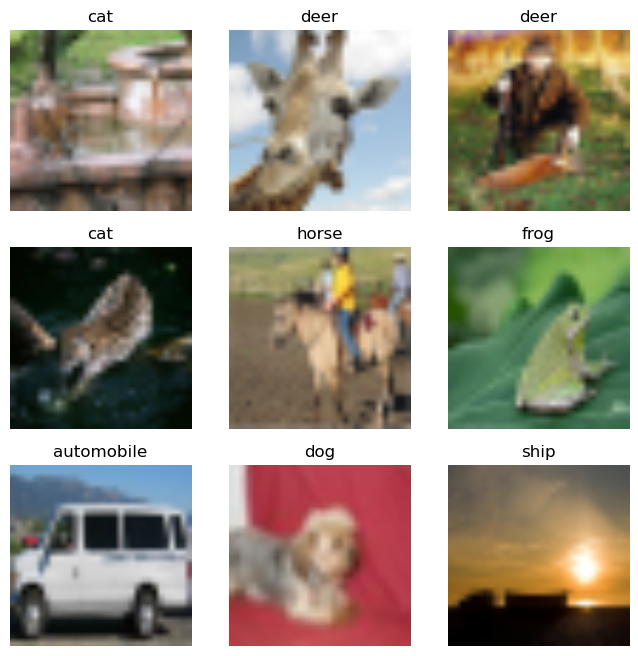

In [ ]:
X_train_batch, y_train_batch = next(iter(train_ds))
idx = np.random.choice(len(X_train_batch), size=9, replace=False)

plt.figure(figsize=(8,8))
for j, i in enumerate(idx):
    plt.subplot(3,3,j+1)
    plt.imshow(X[i].numpy().astype("uint8"), interpolation="bilinear")
    plt.title(class_names[int(y[i])])
    plt.axis("off")
plt.show()